2021-11-30 ~ 2023-12-01 까지 2년치 매일 30건씩

주차로 묶어서 시각화

# Figure 1(Difficulty)

In [6]:
# run_id_2222
visualization_target = input("INPUT 'visualization_target RUN_ID'(e.g., run_id_2222): ")

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
from glob import glob

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting

import lib.annotation.tools.Result_Prep as rp

import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt
import matplotlib as mpl
import lib.visualization.plot_generator as PlotGen
import lib.visualization.figure_setting as figure_setting
mpl.rcParams['font.family'] = figure_setting.init_font()




Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [8]:
viz_dir = f'{path_list["data_root_dir"]}/result/annotate_difficulty/{visualization_target}'
data_dir = f"{viz_dir}/data/csv"
option_dict = load_json(f"{viz_dir}/ver33330000/option.json")
output_dir = create_dir('./fig/')
date_range = 'Weekly'


# std_date = Date_Setting[option_dict['year_range']]['std_date']

In [9]:
path = f"{viz_dir}/{option_dict['operation_option']['llm_model']}"
file_list = os.listdir(path)

In [52]:
file_list

['22220337',
 '22220211',
 '22220278',
 '33330140',
 '33330144',
 '22220244',
 '33330289',
 '33330271',
 '22220234',
 '33330318',
 '33330379',
 '33330280',
 '22220390',
 '33330296',
 '33330114',
 '22220296',
 '33330250',
 '33330014',
 '22220226',
 '22220414',
 '33330302',
 '22220283',
 '33330070',
 '22220302',
 '22220242',
 '22220365',
 '33330315',
 '22220277',
 '22220409',
 '22220321',
 '33330210',
 '22220352',
 '22220406',
 '33330027',
 '33330188',
 '22220319',
 '33330328',
 '22220336',
 '33330170',
 '22220280',
 '22220318',
 '22220254',
 '22220335',
 '22220349',
 '22220271',
 '22220346',
 '33330059',
 '33330057',
 '22220260',
 '33330180',
 '22220351',
 '33330088',
 '22220220',
 '33330224',
 '22220371',
 '33330215',
 '33330089',
 '33330133',
 '33330162',
 '22220399',
 '22220403',
 '33330149',
 '22220379',
 '33330172',
 '33330005',
 '22220397',
 '22220227',
 '33330123',
 '22220385',
 '22220391',
 '22220238',
 '33330001',
 '33330353',
 '33330197',
 '22220303',
 '33330401',
 '33330080',

In [53]:
ver_list = sorted([y for y in [x for x in file_list if x.isdigit()] if (int(y)>=33330000) & (int(y)<33340000)])


In [54]:
ver_list

['33330001',
 '33330002',
 '33330005',
 '33330007',
 '33330010',
 '33330011',
 '33330014',
 '33330015',
 '33330018',
 '33330020',
 '33330022',
 '33330024',
 '33330027',
 '33330028',
 '33330031',
 '33330033',
 '33330036',
 '33330037',
 '33330040',
 '33330041',
 '33330044',
 '33330046',
 '33330049',
 '33330050',
 '33330053',
 '33330054',
 '33330057',
 '33330059',
 '33330062',
 '33330063',
 '33330066',
 '33330067',
 '33330070',
 '33330072',
 '33330075',
 '33330076',
 '33330079',
 '33330080',
 '33330083',
 '33330085',
 '33330088',
 '33330089',
 '33330092',
 '33330094',
 '33330096',
 '33330098',
 '33330101',
 '33330102',
 '33330105',
 '33330107',
 '33330110',
 '33330111',
 '33330114',
 '33330115',
 '33330118',
 '33330120',
 '33330123',
 '33330124',
 '33330127',
 '33330128',
 '33330131',
 '33330133',
 '33330136',
 '33330137',
 '33330140',
 '33330141',
 '33330144',
 '33330146',
 '33330149',
 '33330150',
 '33330153',
 '33330155',
 '33330157',
 '33330159',
 '33330162',
 '33330163',
 '33330166',

In [55]:
r_p = rp.Result_Prep()

In [56]:
tot_calc = pd.DataFrame()
for listid in ver_list:
    df = r_p.make_one_file(listid, path)
    if isinstance(df, pd.core.frame.DataFrame):
        df = r_p.pp_df(df, 5)
        if df.shape[0]>0 :
            df = r_p.calc_rate_byweek(df)
            tot_calc = pd.concat([tot_calc, df], axis = 0)

    

In [57]:
tot_calc

,rel_week,o_result,r_cnt,tot_cnt,rate
0,-51.0,0,63,144,43.750000
1,-51.0,1,68,144,47.222222
2,-51.0,2,13,144,9.027778
0,-50.0,0,49,168,29.166667
1,-50.0,1,98,168,58.333333
...,...,...,...,...,...
0,154.0,1,2,3,66.666667
1,154.0,2,1,3,33.333333
0,155.0,0,1,5,20.000000
1,155.0,1,1,5,20.000000


In [41]:
def draw_complexity_regression(ax, x, y, st_chow_1year,
                               F_stat_1, p_value_1, title,
                               panel_label=''):

    split_idx = np.where(x < 0)[0][-1] + 1

    x1 = x[:split_idx]
    x2 = x[split_idx:]

    # scatter
    ax.scatter(x, y, color='darkgray', alpha=0.7, s=10, marker='x')

    # # Full model
    ax.plot(x, st_chow_1year.y_predict,
            linestyle="--", color="black",
            linewidth=1.5, label='Overall fit')

    # Before ChatGPT
    ax.plot(x1, st_chow_1year.y1_predict,
            linewidth=1.5, label='Before ChatGPT')

    # ax.fill_between(
    #     x1,
    #     st_chow_1year.y1_predict - st_chow_1year.y1_conf_interval,
    #     st_chow_1year.y1_predict + st_chow_1year.y1_conf_interval,
    #     alpha=0.15
    # )

    # # After ChatGPT
    # ax.plot(x2, st_chow_1year.y2_predict,
    #         linewidth=1.5, label='After ChatGPT')

    # ax.fill_between(
    #     x2,
    #     st_chow_1year.y2_predict - st_chow_1year.y2_conf_interval,
    #     st_chow_1year.y2_predict + st_chow_1year.y2_conf_interval,
    #     alpha=0.15
    # )

    # # vertical line
    # ax.axvline(x=0, color='#CC3333', linestyle='--', linewidth=1.2, zorder=5)

    # # p-value text
    # p_txt = '$p < 0.001$' if p_value_1 < 0.001 else f'$p = {p_value_1:.3f}$'
    # p_color = '#CC3333' if p_value_1 < 0.05 else 'gray'

    # # title
    # ax.text(
    #     0.5, 1.08,
    #     f'Changes in {title}',
    #     transform=ax.transAxes,
    #     fontsize=font_setting.font_setting['title'],
    #     ha='center',
    #     va='bottom'
    # )

    # # p-value
    # ax.text(
    #     0.5, 1.02,
    #     p_txt,
    #     ha='center',
    #     fontsize=font_setting.font_setting['p-value'],
    #     color=p_color,
    #     transform=ax.transAxes
    # )

    # # panel label
    # if panel_label:
    #     ax.text(
    #         -0.08, 1.08,
    #         panel_label,
    #         transform=ax.transAxes,
    #         fontsize=font_setting.font_setting['panel'],
    #         fontweight='bold',
    #         va='bottom',
    #         ha='left'
    #     )

    # # axis labels
    # ax.set_xlabel("Week relative to ChatGPT release", fontsize=font_setting.font_setting['label'])
    # ax.set_ylabel("Percentage(%)", fontsize=font_setting.font_setting['label'])

    # # ticks
    # ax.tick_params(axis='both', labelsize=font_setting.font_setting['tick'])

    # # spine
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)

    # # grid
    # ax.yaxis.grid(True, linestyle=':', linewidth=0.5,
    #               color='gray', alpha=0.5, zorder=0)
    # ax.set_axisbelow(True)

    # # legend
    # ax.legend(fontsize=font_setting.font_setting['legend'], frameon=False)

In [48]:
x = chk_cnt['rel_week'].values
y = chk_cnt['rate'].values


split_idx = np.where(x < 0)[0][-1] + 1

x1 = x[:split_idx]
x2 = x[split_idx:]

st_chow = st.Stats(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
F_stat, p_value = st_chow.chow_test()


# # Full model
print(len(x1))
print(len(st_chow.y1_predict))


48
87


In [50]:
chk_cnt

,rel_week,o_result,r_cnt,tot_cnt,rate
0,-51.0,0,63,144,43.750000
1,-50.0,0,49,168,29.166667
2,-50.0,0,65,178,36.516854
3,-49.0,0,32,80,40.000000
4,-47.0,0,55,148,37.162162
...,...,...,...,...,...
170,140.0,0,1,2,50.000000
171,142.0,0,1,4,25.000000
172,150.0,0,1,8,12.500000
173,155.0,0,1,2,50.000000


175
87


ValueError: x and y must have same first dimension, but have shapes (48,) and (87,)

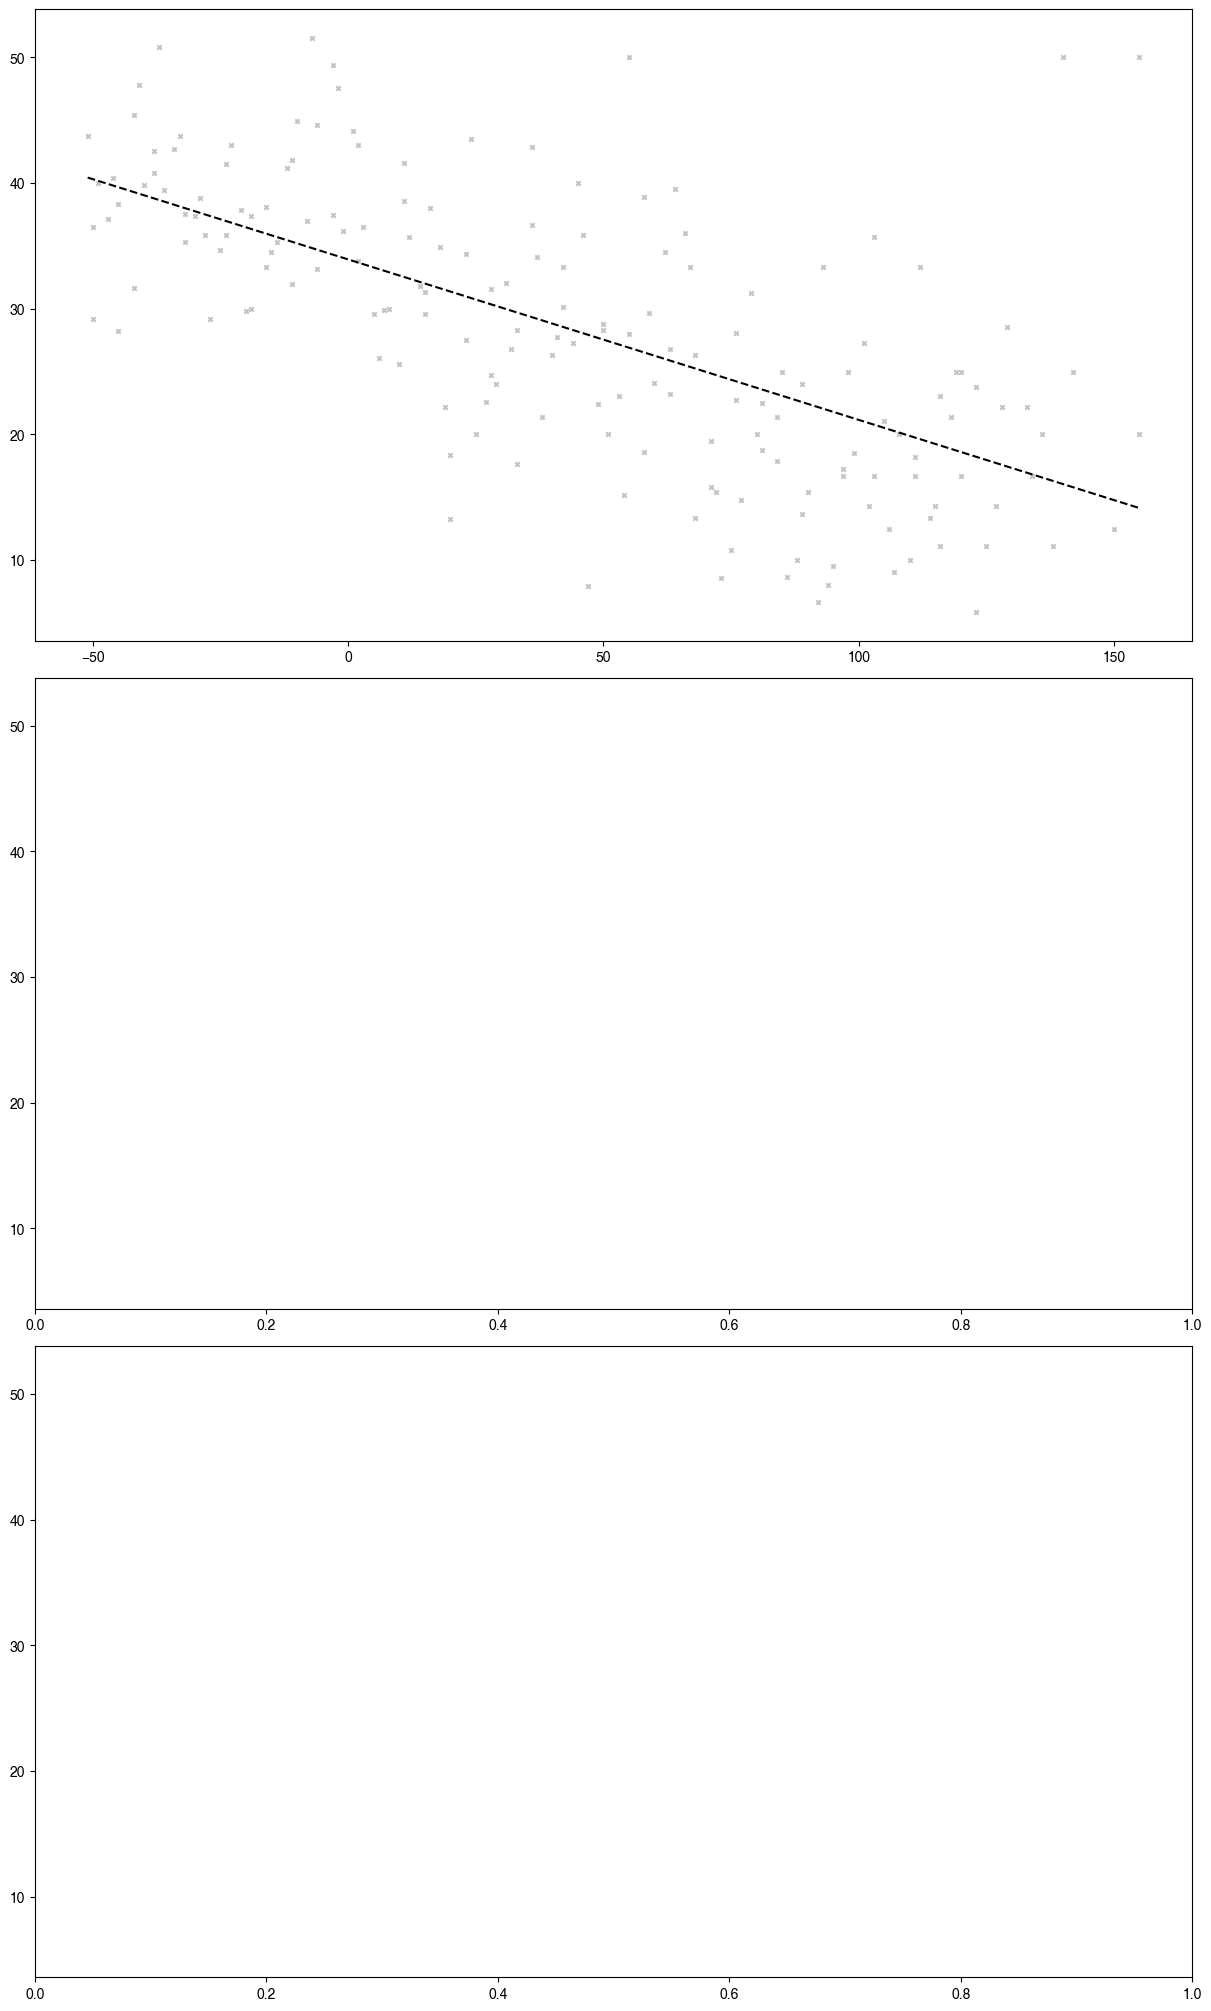

In [43]:
fig, ax = plt.subplots(3, 1, figsize=(12,20), constrained_layout=True, sharey=True)
label_dict = {'A' : 'Basic', 'B' : 'Intermediate', 'C':'Advanced'}

for i, (label, title) in enumerate(label_dict.items()):
    chk_cnt = tot_calc[tot_calc['o_result'] == str(i)].sort_values(by = ['rel_week'], ascending=True).reset_index(drop=True)
    x = chk_cnt['rel_week'].values
    y = chk_cnt['rate'].values

    st_chow = st.Stats(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
    F_stat, p_value = st_chow.chow_test()
    print(len(y))
    print(len(st_chow.y1_predict))
    draw_complexity_regression(
        ax[i],
        x,
        y,
        st_chow,
        F_stat,
        p_value,
        title=f"{title}",
        panel_label=f"{label}"
    )



# plt.savefig(
#     f"{output_dir}/{visualization_target}.png",
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

In [ ]:
x1 = x[:split_idx]

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]),)

In [44]:
x1

NameError: name 'x1' is not defined

'/mnt/hdd/mghan/so_difficulty_measure/result/code_complexity/cyclomatic_complexity/origin_df.json'

In [ ]:
x1, st_chow_1year.y1_predict

NameError: name 'st_chow_1year' is not defined

In [ ]:
np.where(x < 0)[0][-1] + 1

In [18]:
x = chk_cnt['rel_week'].values
y = chk_cnt['rate'].values

In [22]:
len(x)

175

In [21]:
len(y)

175

In [51]:
tot_calc

,rel_week,o_result,r_cnt,tot_cnt,rate
0,-51.0,0,63,144,43.750000
1,-51.0,1,68,144,47.222222
2,-51.0,2,13,144,9.027778
0,-50.0,0,49,168,29.166667
1,-50.0,1,98,168,58.333333
...,...,...,...,...,...
0,154.0,1,2,3,66.666667
1,154.0,2,1,3,33.333333
0,155.0,0,1,5,20.000000
1,155.0,1,1,5,20.000000
